<a href="https://colab.research.google.com/github/Dramy8/DI_Bootcamp/blob/main/Week08/Day5/Ex_XP/Heart_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [1]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [3]:
# TODO: extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)
csv_files = glob.glob(EXTRACT_DIR + "/*.csv")
print(csv_files)

# TODO: list CSV files under EXTRACT_DIR
csv_path = csv_files[0]
  # set to the CSV you choose

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)
df



['heart_ds/dataset_heart.csv']


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,1
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,1
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,1
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,1


In [4]:
# TODO: inspect df

df.columns = df.columns.str.strip()

In [5]:
df.head()


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


In [35]:
df['heart disease'] = df['heart disease'].map({1: 0, 2: 1})

In [36]:

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major vessels      

In [37]:
df.describe()


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000


In [38]:

df.isnull().sum()



,0
age,0
sex,0
chest pain type,0
resting blood pressure,0
serum cholestoral,0
fasting blood sugar,0
resting electrocardiographic results,0
max heart rate,0
exercise induced angina,0
oldpeak,0


In [39]:
df.columns

Index(['age', 'sex', 'chest pain type', 'resting blood pressure',
       'serum cholestoral', 'fasting blood sugar',
       'resting electrocardiographic results', 'max heart rate',
       'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels',
       'thal', 'heart disease'],
      dtype='object')

In [40]:
# TODO: identify target column
target = 'heart disease' # 'target'

# TODO: split features and target
X = df.drop(columns=[target]) # df.drop(columns=[...])
y = df[target]  # df[...]

# TODO: train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
# Hint: train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

### Basic visual checks

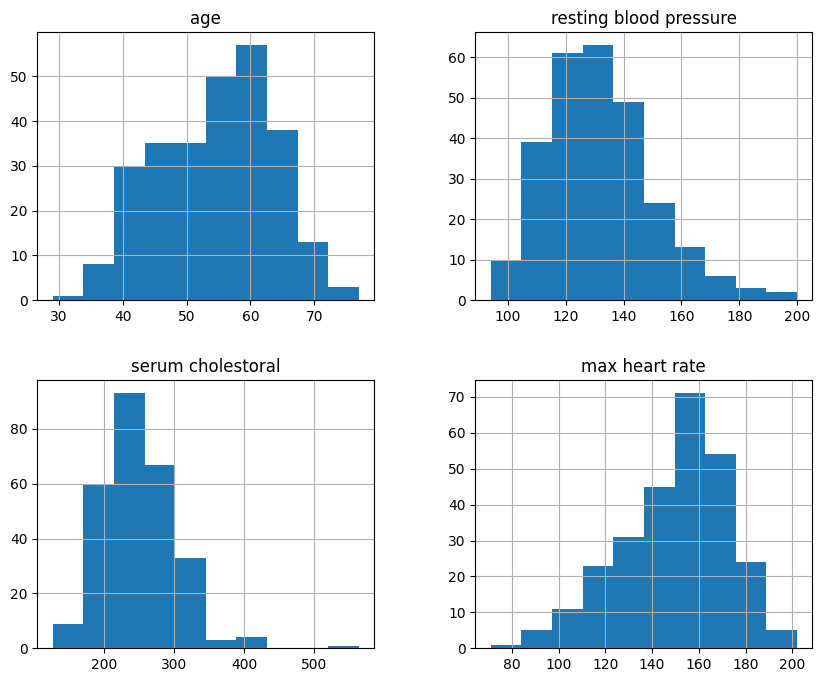

In [41]:
# TODO: pick a few numeric columns and plot histograms
cols = [
    'age',
    'resting blood pressure',
    'serum cholestoral',
    'max heart rate'
]

df[cols].hist(figsize=(10,8))

plt.show()



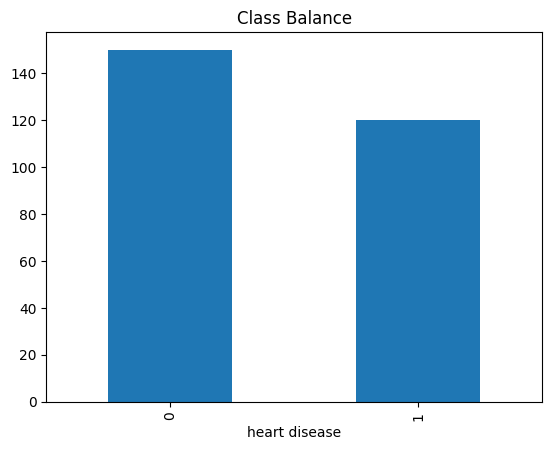

In [42]:
# TODO: plot class balance as a bar chart

eff = y.value_counts()

eff.plot(kind='bar')

plt.title('Class Balance')

plt.show()

## Preprocessing pipeline

In [43]:
cat_cols = [
    'sex',
    'chest pain type',
    'fasting blood sugar',
    'resting electrocardiographic results',
    'exercise induced angina',
    'ST segment',
    'major vessels',
    'thal'
]
  # list of object, category, or bool columns
num_cols = [
    'age',
    'resting blood pressure',
    'serum cholestoral',
    'max heart rate',
    'oldpeak'
]
# list of numeric columns



In [44]:
# TODO: build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)



## Helper - evaluation function

In [45]:
def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)  # model.predict(...)

    # TODO: compute metrics dict with accuracy, precision, recall, f1

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }

    # TODO: confusion matrix plot

    cm = confusion_matrix(y_test, y_pred)

    plt.imshow(cm)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.colorbar()
    plt.show()
    # Hint: confusion_matrix(y_test, y_pred)
    # Draw with plt.imshow or ConfusionMatrixDisplay

    # TODO: ROC curve if model has predict_proba

    return metrics


## Exercise 2 - Logistic Regression without Grid Search

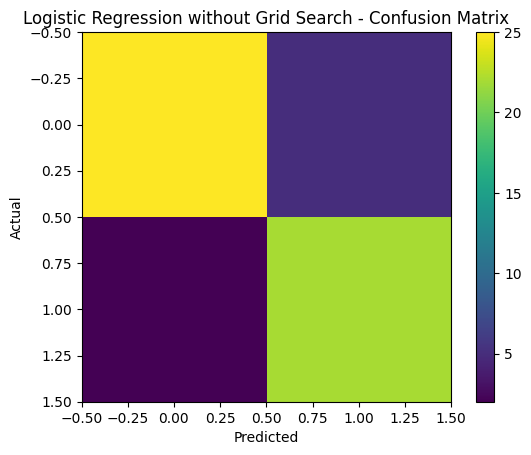

In [46]:
# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = Pipeline([
    ('preprocessor', pre),
    ('model', LogisticRegression(
        solver='liblinear',
        max_iter=1000
    ))
])

# TODO: fit on training data
# pipe_lr.fit(...)
pipe_lr.fit(X_train, y_train)
# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report(
    'Logistic Regression without Grid Search',
    pipe_lr,
    X_test,
    y_test
)


## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}


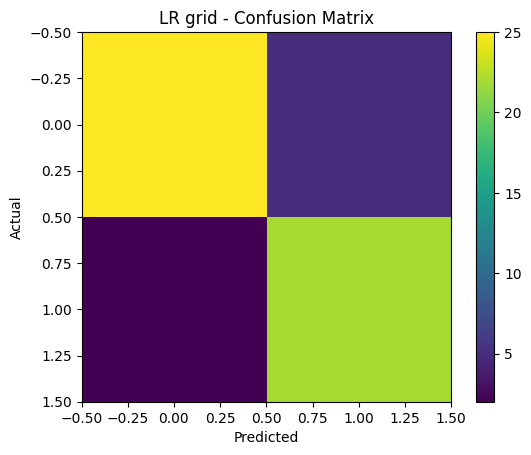

In [47]:
# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline([
    ('preprocessor', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000))
])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(
    pipe_lr_cv,
    param_grid,
    cv=5,
    scoring='f1'
)
# grid_lr.fit(...)
grid_lr.fit(X_train, y_train)
# print('Best params:', grid_lr.best_params_)
print('Best params:', grid_lr.best_params_)
# best_lr = grid_lr.best_estimator_
best_lr = grid_lr.best_estimator_
# lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)
lr_gs_metrics = eval_and_report(
    'LR grid',
    best_lr,
    X_test,
    y_test
)

## Exercise 4 - SVM without Grid Search

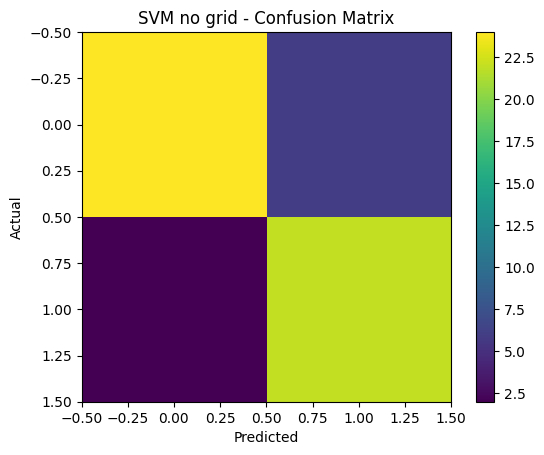

In [48]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline([
    ('preprocessor', pre),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

# pipe_svm.fit(...)
pipe_svm.fit(X_train, y_train)

# svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)
svm_no_metrics = eval_and_report(
    'SVM no grid',
    pipe_svm,
    X_test,
    y_test
)

## Exercise 5 - SVM with Grid Search

Best params: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}


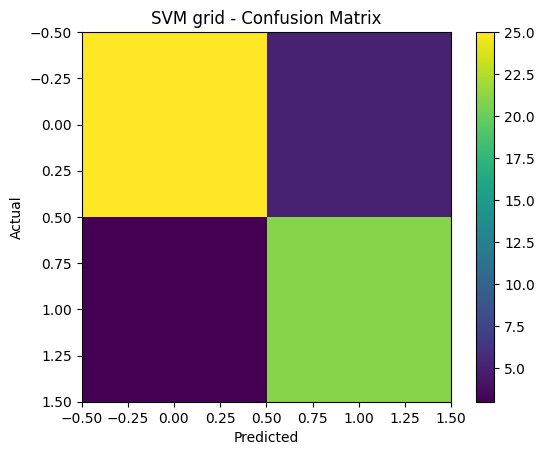

In [49]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline([
    ('preprocessor', pre),
    ('svm', SVC(probability=True))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto']
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(
    pipe_svm_cv,
    svm_param_grid,
    cv=5,
    scoring='f1'
)
# best_svm = grid_svm.best_estimator_
grid_svm.fit(X_train, y_train)
print('Best params:', grid_svm.best_params_)
best_svm = grid_svm.best_estimator_

svm_gs_metrics = eval_and_report(
    'SVM grid',
    best_svm,
    X_test,
    y_test
)
# svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)


## Exercise 6 - XGBoost without Grid Search

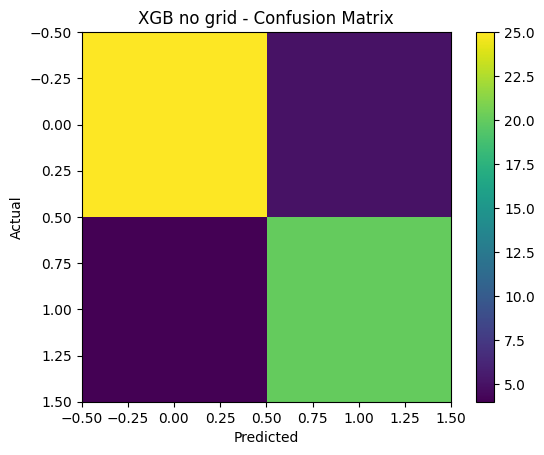

In [51]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = Pipeline([
    ('preprocessor', pre),
    ('xgb', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    ))
])


# pipe_xgb.fit(...)
pipe_xgb.fit(X_train, y_train)
# xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)
xgb_no_metrics = eval_and_report(
    'XGB no grid',
    pipe_xgb,
    X_test,
    y_test
)

## Exercise 7 - XGBoost with Grid Search

Best params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 5, 'xgb__n_estimators': 300, 'xgb__subsample': 0.8}


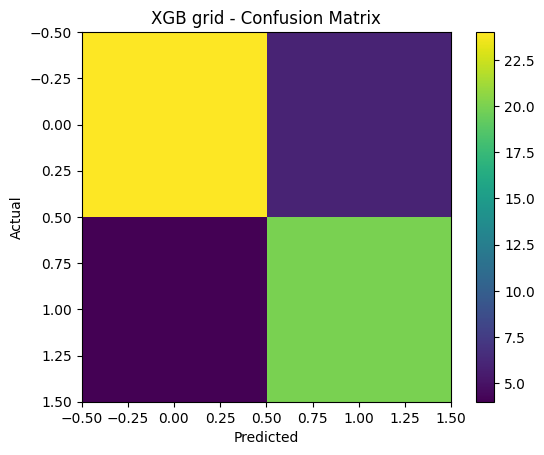

In [52]:
# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline([
    ('preprocessor', pre),
    ('xgb', XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    ))
])

# TODO: define a reasonable param_grid
xgb_param_grid = {
    'xgb__n_estimators': [100, 300],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__max_depth': [3, 5],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(
    pipe_xgb_cv,
    xgb_param_grid,
    cv=5,
    scoring='f1'
)
# best_xgb = grid_xgb.best_estimator_
grid_xgb.fit(X_train, y_train)
# xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)
print('Best params:', grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_

xgb_gs_metrics = eval_and_report(
    'XGB grid',
    best_xgb,
    X_test,
    y_test,
)

## Compare models

In [53]:
# TODO: build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')
summary = {
    'LR no grid': lr_no_gs_metrics,
    'LR grid': lr_gs_metrics,
    'SVM no grid': svm_no_metrics,
    'SVM grid': svm_gs_metrics,
    'XGB no grid': xgb_no_metrics,
    'XGB grid': xgb_gs_metrics
}
# summary['LR no grid'] = lr_no_gs_metrics
# ... add others you computed ...
summary_df = pd.DataFrame.from_dict(summary, orient='index')

summary_df

,accuracy,precision,recall,f1
LR no grid,0.870370,0.814815,0.916667,0.862745
LR grid,0.870370,0.814815,0.916667,0.862745
SVM no grid,0.851852,0.785714,0.916667,0.846154
SVM grid,0.851852,0.807692,0.875000,0.840000
XGB no grid,0.833333,0.800000,0.833333,0.816327
XGB grid,0.814815,0.769231,0.833333,0.800000
